# Colab paso a paso: Desafío RGB

Acá vas a convertir una imagen en una tabla de colores, exportar un CSV, reconstruir un PNG y dejar lista la evidencia para tu entrega individual.

**Privacidad:** usá fotos propias solo si la actividad lo permite. Evitá imágenes personales o sensibles.

**Evidencia de logro:** terminás con archivos nombrados con tu alias, por ejemplo `HARPIR-rgb-discovery-output.csv` y `HARPIR-rgb-discovery-revealed.png`.


In [13]:
from pathlib import Path
import importlib.util
import sys
import urllib.request

HELPER_URL = "https://raw.githubusercontent.com/HaroldSthid/VibePixel-AcademyBabyStepsTech/main/artifacts/colab/rgb_discovery_tools.py"
HELPER_PATH = Path("rgb_discovery_tools.py")
DOWNLOAD_TIMEOUT_SECONDS = 10
EXPECTED_HELPER_VERSION = "1.1.0"
REQUIRED_HELPER_ATTRIBUTES = (
    "normalize_student_alias",
    "resolve_source_image",
    "write_rgb_csv",
    "rebuild_png_from_csv",
)

def _download_file(url, destination, *, label):
    try:
        with urllib.request.urlopen(url, timeout=DOWNLOAD_TIMEOUT_SECONDS) as response:
            destination.write_bytes(response.read())
    except Exception as exc:
        raise FileNotFoundError("No pudimos descargar rgb_discovery_tools.py automáticamente. Verificá tu conexión a internet y volvé a ejecutar esta celda.") from exc

def _helper_supports_required_api(module):
    return (
        getattr(module, "HELPER_VERSION", None) == EXPECTED_HELPER_VERSION
        and all(hasattr(module, name) for name in REQUIRED_HELPER_ATTRIBUTES)
    )

def _load_helper():
    needs_refresh = not HELPER_PATH.exists()
    helper_module = None

    if not needs_refresh:
        spec = importlib.util.spec_from_file_location("rgb_discovery_tools", HELPER_PATH)
        helper_module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(helper_module)
        needs_refresh = not _helper_supports_required_api(helper_module)

    if needs_refresh:
        _download_file(HELPER_URL, HELPER_PATH, label="rgb_discovery_tools.py")
        spec = importlib.util.spec_from_file_location("rgb_discovery_tools", HELPER_PATH)
        helper_module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(helper_module)

    sys.modules["rgb_discovery_tools"] = helper_module

    if not _helper_supports_required_api(helper_module):
        raise AttributeError("El archivo de apoyo no se pudo actualizar con la versión correcta. Reiniciá el runtime y volvé a ejecutar la primera celda.")

    return helper_module, needs_refresh

rgb, helper_refreshed = _load_helper()

if helper_refreshed:
    print("Actualizamos el archivo de apoyo automáticamente; volvé a ejecutar si Colab lo pide.")
else:
    print("Listo: cargamos el helper para trabajar con la imagen y el CSV.")


Listo: cargamos el helper para trabajar con la imagen y el CSV.


## Paso 1 · Elegí la imagen

Si no subís nada, el notebook usa la imagen de ejemplo del proyecto. Si querés trabajar con tu JPG o PNG, cargalo en Colab y cambiá la variable `uploaded_image_path`.

**Evidencia de logro:** ves la imagen elegida y entendés cuál va a convertirse en datos.


Imagen elegida: /content/Screenshot 2026-09-16 at 4.10.25 PM.png
Tamaño original: (764, 924)
Tamaño de estudio: (40, 48)


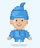

In [14]:
from IPython.display import display

uploaded_image_path = "/content/Screenshot 2026-09-16 at 4.10.25 PM.png"
source_image_path = rgb.resolve_source_image(uploaded_image_path or None)
source_image = rgb.open_rgb_image(source_image_path)
study_image = rgb.fit_study_image(source_image, max_side=rgb.DEFAULT_MAX_SIDE)

print(f"Imagen elegida: {source_image_path}")
print(f"Tamaño original: {source_image.size}")
print(f"Tamaño de estudio: {study_image.size}")
display(study_image)


## Tu alias de entrega

Usá 6 letras en mayúsculas, derivadas como 3 letras de tu nombre + 3 letras de tu apellido. Si te llamás Harold Piravaguen, tu alias es HARPIR.

**Evidencia de logro:** ya tenés el alias listo para nombrar tus archivos sin mostrar tu nombre completo.


In [15]:
student_alias = input("Ingresá tu alias de 6 letras (3 de tu nombre + 3 de tu apellido, por ejemplo HARPIR): ")
student_alias = rgb.normalize_student_alias(student_alias)
print(f"Alias de entrega: {student_alias}")


Ingresá tu alias de 6 letras (3 de tu nombre + 3 de tu apellido, por ejemplo HARPIR): VALMON
Alias de entrega: VALMON


## Paso 2 · Convertí la imagen en datos

Cada píxel pasa a una fila con fila, columna, RGB y hexadecimal. Ese es el puente entre imagen y planilla.

**Evidencia de logro:** la tabla muestra valores de color claros y repetibles.


In [16]:
rows = rgb.image_to_rgb_rows(study_image)
csv_path = rgb.write_rgb_csv(study_image, rgb.student_output_filename(student_alias, rgb.DEFAULT_OUTPUT_CSV))

print(f"CSV exportado en: {csv_path}")
print("Primeras filas de ejemplo:")
rows[:8]


CSV exportado en: VALMON-rgb-discovery-output.csv
Primeras filas de ejemplo:


[{'row': '0',
  'col': '0',
  'r': '237',
  'g': '248',
  'b': '254',
  'hex': '#EDF8FE'},
 {'row': '0',
  'col': '1',
  'r': '237',
  'g': '248',
  'b': '254',
  'hex': '#EDF8FE'},
 {'row': '0',
  'col': '2',
  'r': '237',
  'g': '248',
  'b': '254',
  'hex': '#EDF8FE'},
 {'row': '0',
  'col': '3',
  'r': '237',
  'g': '248',
  'b': '254',
  'hex': '#EDF8FE'},
 {'row': '0',
  'col': '4',
  'r': '237',
  'g': '248',
  'b': '254',
  'hex': '#EDF8FE'},
 {'row': '0',
  'col': '5',
  'r': '237',
  'g': '248',
  'b': '254',
  'hex': '#EDF8FE'},
 {'row': '0',
  'col': '6',
  'r': '237',
  'g': '248',
  'b': '254',
  'hex': '#EDF8FE'},
 {'row': '0',
  'col': '7',
  'r': '237',
  'g': '248',
  'b': '254',
  'hex': '#EDF8FE'}]

## Paso 3 · Reconstruí la imagen

Ahora volvemos del CSV a una imagen para comprobar que los datos estaban completos.

**Evidencia de logro:** el PNG reconstruido se ve igual que la imagen de estudio.


PNG reconstruido en: VALMON-rgb-discovery-revealed.png


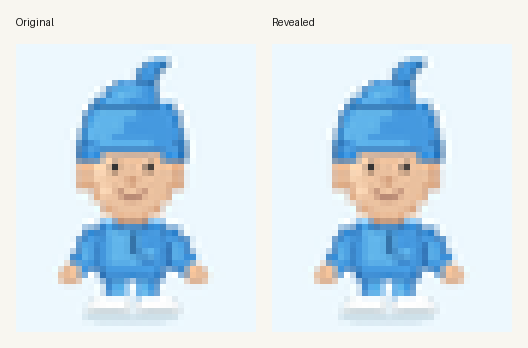

In [17]:
revealed_png_path = rgb.rebuild_png_from_csv(csv_path, rgb.student_output_filename(student_alias, rgb.DEFAULT_OUTPUT_PNG))
revealed_image = rgb.open_rgb_image(revealed_png_path)
comparison_panel = rgb.make_comparison_panel(study_image, revealed_image)

print(f"PNG reconstruido en: {revealed_png_path}")
display(comparison_panel)


## Paso 4 · Prepará la entrega individual

Guardá los dos archivos finales con tu alias y dejalos listos para compartir en tu entrega Top 10.

**Evidencia de logro:** tenés un CSV y un PNG con nombres claros para entregar dentro de `submissions/<ALIAS>/`.


In [18]:
submission = rgb.prepare_submission_assets(csv_path, revealed_png_path, Path("submissions"), student_alias)
print("Archivos listos para compartir:")
print(f"- CSV: {submission['csv']}")
print(f"- PNG: {submission['png']}")
print(f"- Carpeta: {submission['folder']}")


Archivos listos para compartir:
- CSV: submissions/VALMON/VALMON-rgb-discovery-output.csv
- PNG: submissions/VALMON/VALMON-rgb-discovery-revealed.png
- Carpeta: submissions/VALMON


## Cierre

Si llegaste hasta acá, ya hiciste el recorrido completo: imagen → datos → imagen.

**Qué te llevás:** una evidencia visible, un CSV exportado y un PNG reconstruido para tu presentación o entrega.
